# Minimum absolute Hamiltonian eigenvalue versus transverse size
Analyze the same 100 independent disordered ground-state Hamiltonians at each $N_x=12,16,20,24,32,40$, with $N_y=40$ and $W^2=9$. Disorder acts only on the wall columns $x=N_x/4,3N_x/4$, independently for every $y$ and orbital. The canonical CPU OW parent has $\alpha_1=1,\alpha_2=30,n_{\rm shell}=1$, hard-wall truncation, and trial orbitals X. No reflattening or energy rescaling.

For each realization $s$, calculate the requested zero-referenced spectral distance and then average:
$$g_s=\min_i|E_{i,s}|,\qquad \bar g=\frac1{100}\sum_s g_s,\qquad
\mathrm{SEM}(\bar g)=\frac{\mathrm{std}(g_s;\mathrm{ddof}=1)}{\sqrt{100}}.$$
The minimum is taken within each Hamiltonian before averaging; no ensemble-wide minimum or averaged Hamiltonian is used. Energies keep the saved Hamiltonian's original zero. All eigenvalues, including any zero modes, are retained. No diagonalization or dynamics is repeated.

For diagnostic clarity, also record the fixed-particle-number excitation gap $E_{N+1}-E_N$ and midgap chemical potential $(E_N+E_{N+1})/2$, with $N=N_xN_y$. These are distinct from the plotted $\min_i|E_i|$ when disorder shifts the half-filling chemical potential. Each Hamiltonian provides one independent gap value; no cut-origin averaging applies to this full-system observable.

In [1]:
import os
CPU_RANGE=(40,43)
selected=list(range(CPU_RANGE[0],CPU_RANGE[1]+1))
assert set(selected).issubset(os.sched_getaffinity(0))
os.sched_setaffinity(0,selected)
for key in ('OPENBLAS_NUM_THREADS','MKL_NUM_THREADS','OMP_NUM_THREADS'):os.environ[key]='1'
print('Allocated CPUs:',selected)

Allocated CPUs: [40, 41, 42, 43]


## Configuration and verified spectra
Read all 600 original spectra, validate sample identity, byte count and SHA-256, and cross-check the saved half-filling gap. Nx20 uses the original reused sample paths.

In [2]:
from pathlib import Path
import json,hashlib,subprocess
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from IPython.display import display,Image
OUT=Path.cwd();SOURCE=OUT.parent/'disordered_exact_wall_Nx_scan_Ny040_W2_9_v1'
SIZES=[12,16,20,24,32,40];NY=40;W2=9;SAMPLES=100
BOOTSTRAPS=5000;BOOTSTRAP_SEED=2026092801
ZERO_DIAGNOSTIC_TOL=1e-10
def sha(p):return hashlib.sha256(p.read_bytes()).hexdigest()
source_provenance=json.loads((SOURCE/'input_provenance.json').read_text())
assert source_provenance['configuration']['Ny']==NY and source_provenance['configuration']['variance']==W2
source_manifest=json.loads((SOURCE/'completion_manifest.json').read_text())
assert source_manifest['status']=='complete' and source_manifest['sizes']==SIZES
rows=[];inputs=[];spectra={};max_saved_gap_error=0.
for nx in tqdm(SIZES,desc='Validate Hamiltonian spectra',unit='size'):
    rp=SOURCE/f'Nx{nx:03d}/acquisition_complete.json';acq=json.loads(rp.read_text())
    assert acq['status']=='complete' and acq['identity']==source_provenance['identity']
    assert acq['Nx']==nx and acq['Ny']==NY and acq['samples']==SAMPLES and acq['variance']==W2
    reused=acq.get('reused_inputs')
    prior_provenance=None
    if reused is not None:
        prior_root=Path(reused[0]['path']).parents[2]
        prior_provenance=json.loads((prior_root/'input_provenance.json').read_text())
        assert prior_provenance['configuration']['disorder_x_columns']==[nx//4,3*nx//4]
        expected_identity=prior_provenance['identity']
    else:expected_identity=source_provenance['identity']
    paths=[Path(v['path']) for v in reused] if reused is not None else [SOURCE/f'Nx{nx:03d}/realizations/sample_{sid:03d}.npz' for sid in range(SAMPLES)]
    seen=[];energies=[]
    for sid,p in enumerate(paths):
        r=json.loads(p.with_suffix('.json').read_text())
        assert r['identity']==expected_identity and r['sample_id']==sid and r['Ny']==NY and r['variance']==W2
        assert r['filename']==p.name and r['bytes']==p.stat().st_size and r['sha256']==sha(p)
        if reused is not None:
            assert reused[sid]['sha256']==r['sha256'] and reused[sid]['bytes']==r['bytes']
        with np.load(p) as z:
            assert int(z['sample_id'])==sid and int(z['Ny'])==NY and int(z['variance'])==W2
            assert np.array_equal(z['seed_components'],r['seed_components'])
            e=z['hamiltonian_energies'];potential=z['diagonal_potential']
        assert e.shape==(2*nx*NY,) and np.isrealobj(e) and np.isfinite(e).all()
        assert np.all(np.diff(e)>=-1e-12)
        mask=np.isin(np.arange(2*nx*NY)//2%nx,[nx//4,3*nx//4])
        assert np.all(potential[~mask]==0)
        n=nx*NY;j=int(np.argmin(np.abs(e)));gap=float(e[n]-e[n-1])
        error=abs(gap-r['diagnostics']['half_filling_gap']);max_saved_gap_error=max(max_saved_gap_error,error)
        assert error<1e-12 and gap>0
        rows.append(dict(Nx=nx,Ny=NY,W2=W2,sample_id=sid,min_abs_eigenvalue=float(abs(e[j])),
            nearest_signed_eigenvalue=float(e[j]),nearest_level_index=j,
            E_highest_occupied=float(e[n-1]),E_lowest_unoccupied=float(e[n]),
            half_filling_gap=gap,midgap_chemical_potential=float((e[n]+e[n-1])/2),
            negative_levels=int(np.count_nonzero(e<0)),near_zero_levels=int(np.count_nonzero(np.abs(e)<=ZERO_DIAGNOSTIC_TOL))))
        seen.append(sid);energies.append(e)
        inputs.append(dict(Nx=nx,sample_id=sid,path=str(p),bytes=r['bytes'],sha256=r['sha256'],identity=r['identity']))
    assert seen==list(range(SAMPLES))
    spectra[nx]=np.array(energies)
samples=pd.DataFrame(rows)
samples.to_csv(OUT/'sample_gaps.csv',index=False)
np.savez_compressed(OUT/'hamiltonian_eigenvalues.npz',**{f'energies_Nx{nx:03d}':spectra[nx] for nx in SIZES},Nx_values=SIZES,Ny=NY,W2=W2,sample_ids=np.arange(SAMPLES))
metadata=dict(Ny=NY,W2=W2,Nx_values=SIZES,samples_per_size=SAMPLES,disorder_support='x=Nx/4,3Nx/4; independent y and orbital',
 estimator='arithmetic disorder mean of per-realization min(abs(E)); original energy zero; no rescaling',
 uncertainty='one SEM across independent Hamiltonians',source_campaign=str(SOURCE),no_new_diagonalizations=True)
(OUT/'input_provenance.json').write_text(json.dumps(dict(configuration=metadata,source_provenance=source_provenance,inputs=inputs),indent=2)+'\n')
display(pd.Series(metadata))

Validate Hamiltonian spectra:   0%|          | 0/6 [00:00<?, ?size/s]

Ny                                                                        40
W2                                                                         9
Nx_values                                           [12, 16, 20, 24, 32, 40]
samples_per_size                                                         100
disorder_support                     x=Nx/4,3Nx/4; independent y and orbital
estimator                  arithmetic disorder mean of per-realization mi...
uncertainty                          one SEM across independent Hamiltonians
source_campaign            /home/abhuiyan/class_A_fermionic_adaptive_circ...
no_new_diagonalizations                                                 True
dtype: object

## Gap statistics
Save the mean, SEM, median, quantiles and sample range. Bootstrap complete Hamiltonians for a 95% interval on the mean and on the Nx40 minus Nx12 difference.

In [3]:
rng=np.random.default_rng(BOOTSTRAP_SEED)
summary_rows=[];boot=[];gaps=[]
for nx in SIZES:
    t=samples[samples.Nx==nx].sort_values('sample_id')
    g=t.min_abs_eigenvalue.to_numpy();assert len(g)==SAMPLES and np.all(g>=0)
    b=g[rng.integers(0,SAMPLES,size=(BOOTSTRAPS,SAMPLES))].mean(1)
    lo,hi=np.quantile(b,[.025,.975]);q25,q75=np.quantile(g,[.25,.75])
    summary_rows.append(dict(Nx=nx,Ny=NY,W2=W2,samples=SAMPLES,wall_separation=nx//2,
       mean_min_abs_eigenvalue=float(g.mean()),sem=float(g.std(ddof=1)/np.sqrt(SAMPLES)),
       median=float(np.median(g)),q25=float(q25),q75=float(q75),minimum=float(g.min()),maximum=float(g.max()),
       mean_ci_low=float(lo),mean_ci_high=float(hi),mean_half_filling_gap=float(t.half_filling_gap.mean()),
       mean_midgap_chemical_potential=float(t.midgap_chemical_potential.mean())))
    boot.append(b);gaps.append(g)
summary=pd.DataFrame(summary_rows)
summary.to_csv(OUT/'gap_summary.csv',index=False)
np.savez_compressed(OUT/'gap_statistics.npz',Nx_values=SIZES,sample_ids=np.arange(SAMPLES),min_abs_eigenvalues=gaps,bootstrap_means=boot,bootstrap_seed=BOOTSTRAP_SEED)
delta=summary.iloc[-1].mean_min_abs_eigenvalue-summary.iloc[0].mean_min_abs_eigenvalue
delta_sem=float(np.hypot(summary.iloc[-1]['sem'],summary.iloc[0]['sem']))
lo,hi=np.quantile(boot[-1]-boot[0],[.025,.975])
endpoint=dict(delta_mean_Nx40_minus_Nx12=float(delta),sem=delta_sem,bootstrap_ci_low=float(lo),bootstrap_ci_high=float(hi))
(OUT/'endpoint_comparison.json').write_text(json.dumps(endpoint,indent=2)+'\n')
display(summary[['Nx','mean_min_abs_eigenvalue','sem','median','mean_half_filling_gap']])
display(pd.Series(endpoint))

,Nx,mean_min_abs_eigenvalue,sem,median,mean_half_filling_gap
0,12,0.016522,0.001324,0.014254,0.060538
1,16,0.019843,0.001416,0.017035,0.055842
2,20,0.019896,0.001390,0.016920,0.053244
3,24,0.021220,0.001513,0.018398,0.058346
4,32,0.018980,0.001437,0.016254,0.056306
5,40,0.019995,0.001368,0.017749,0.056287


delta_mean_Nx40_minus_Nx12    0.003473
sem                           0.001904
bootstrap_ci_low             -0.000238
bootstrap_ci_high             0.007117
dtype: float64

## Minimum absolute eigenvalue versus Nx
One point per size: arithmetic mean of the 100 per-Hamiltonian minima, with one-SEM error bars. Plot uses the saved Hamiltonian energy units.

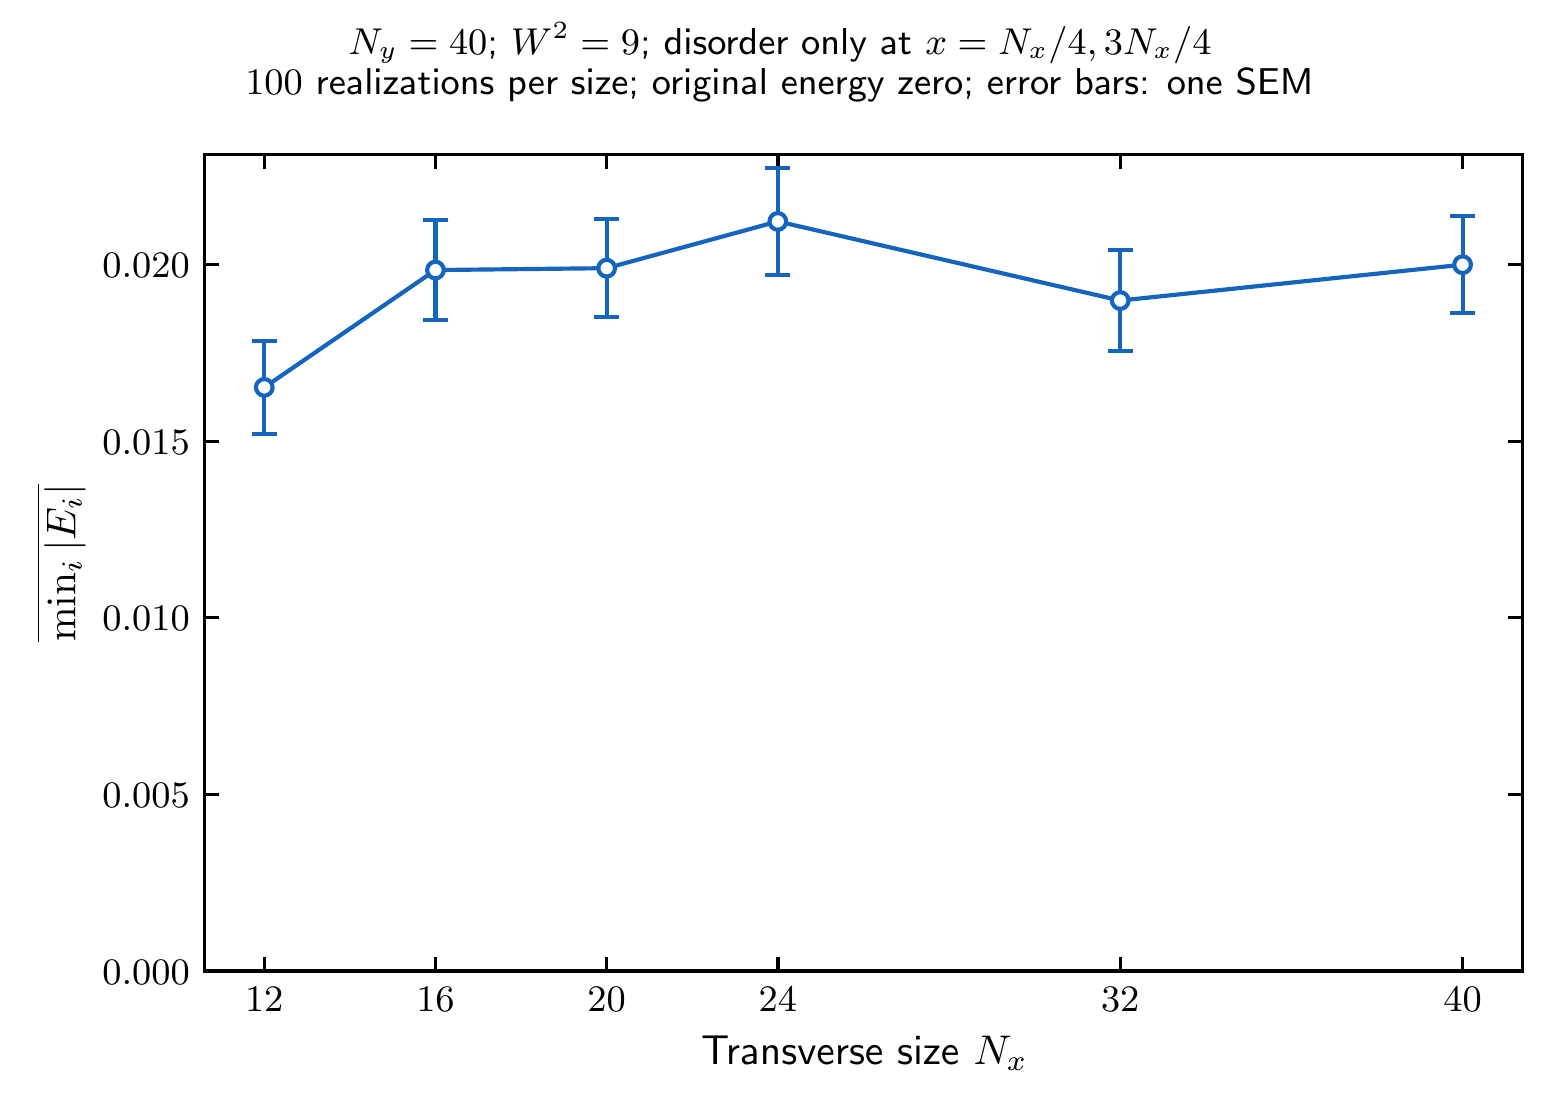

In [4]:
import matplotlib as mpl
import matplotlib.pyplot as plt
os.environ['TEXINPUTS']=str(OUT/'latex_support')+os.pathsep+os.environ.get('TEXINPUTS','')
mpl.rcParams.update({'font.family':'sans-serif','font.sans-serif':['CMU Sans Serif'],'font.size':9,
 'axes.labelsize':10,'axes.titlesize':10,'text.usetex':True,'text.latex.preamble':r'\usepackage{amsmath,amssymb}',
 'xtick.direction':'in','ytick.direction':'in','legend.frameon':False,'legend.fontsize':8,'pdf.fonttype':42})
fig,ax=plt.subplots(figsize=(5.2,3.7))
ax.errorbar(summary.Nx,summary.mean_min_abs_eigenvalue,yerr=summary['sem'],fmt='o-',color='#1565c0',
 mfc='white',ms=4,capsize=3,lw=1,label='Disorder mean')
ax.set(xlabel=r'Transverse size $N_x$',ylabel=r'$\overline{\min_i|E_i|}$',xticks=SIZES,ylim=(0,None))
ax.tick_params(top=True,right=True)
fig.suptitle(r'$N_y=40$; $W^2=9$; disorder only at $x=N_x/4,3N_x/4$'+'\n'+
 r'$100$ realizations per size; original energy zero; error bars: one SEM',fontsize=9)
fig.tight_layout(pad=1)
fig.savefig(OUT/'minimum_absolute_eigenvalue_vs_Nx.pdf');plt.close(fig)
subprocess.run(['pdftoppm','-r','300','-singlefile','-png',str(OUT/'minimum_absolute_eigenvalue_vs_Nx.pdf'),str(OUT/'minimum_absolute_eigenvalue_vs_Nx')],check=True)
display(Image(filename=str(OUT/'minimum_absolute_eigenvalue_vs_Nx.png'),width=900))

## Diagnostics
All levels are retained. No near-zero censoring, eigenvalue clipping, spectrum centering, or matrix averaging. The half-filling gap is cross-checked against the original acquisition receipts.

In [5]:
diagnostics=dict(configuration=metadata,total_hamiltonians=len(samples),levels_by_size={str(nx):2*nx*NY for nx in SIZES},
 exact_zero_minima=int((samples.min_abs_eigenvalue==0).sum()),
 near_zero_minima=int((samples.min_abs_eigenvalue<=ZERO_DIAGNOSTIC_TOL).sum()),zero_diagnostic_tolerance=ZERO_DIAGNOSTIC_TOL,
 max_saved_half_filling_gap_error=max_saved_gap_error,endpoint_comparison=endpoint,
 checks={'input_checksums':True,'unique_sample_ids':True,'finite_real_sorted_eigenvalues':True,'wall_only_disorder_support':True},
 bootstrap={'replicates':BOOTSTRAPS,'seed':BOOTSTRAP_SEED,'unit':'whole Hamiltonian'},
 distinction='min(abs(E)) uses original E=0; fixed-N excitation gap is E[N]-E[N-1] with zero-based indexing')
(OUT/'diagnostics.json').write_text(json.dumps(diagnostics,indent=2)+'\n')
display(pd.Series(diagnostics))
print('Complete: all 600 saved Hamiltonian spectra validated.')

configuration                       {'Ny': 40, 'W2': 9, 'Nx_values': [12, 16, 20, ...
total_hamiltonians                                                                600
levels_by_size                      {'12': 960, '16': 1280, '20': 1600, '24': 1920...
exact_zero_minima                                                                   0
near_zero_minima                                                                    0
zero_diagnostic_tolerance                                                         0.0
max_saved_half_filling_gap_error                                                  0.0
endpoint_comparison                 {'delta_mean_Nx40_minus_Nx12': 0.0034727292542...
checks                              {'input_checksums': True, 'unique_sample_ids':...
bootstrap                           {'replicates': 5000, 'seed': 2026092801, 'unit...
distinction                         min(abs(E)) uses original E=0; fixed-N excitat...
dtype: object

Complete: all 600 saved Hamiltonian spectra validated.
